In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from contrib.common import read_json

In [65]:
METRIC_LIST = ['depth_ratio', 'ops_ratio', 'cx_ratio']


In [52]:
def get_ours_metrics(dir:  Path):
    if not isinstance(dir, Path):
        dir = Path(dir)
    assert dir.is_dir(), dir

    records = []
    for subdir in dir.iterdir():
        try:
            metrics = read_json(subdir / 'metrics.json')
            config = read_json(subdir / 'config.json')
        except:
            continue
        rec = {key.replace('metric/', ''): value for key, value in metrics.items()}
        rec.update(graph_name=config['hardware'].lower(),
                   circuit=config['circuit'],
                   layout_method=config['init_strategy'].lower() + '-ours',
                   opt_method='ours',
                   routing_method='ours',
                   opt_order='ours')
        records.append(rec)

    return pd.DataFrame.from_records(records)

df_ours = get_ours_metrics('./output/ours/nam_circs')

In [7]:
df_ours

,depth_ratio,ops_ratio,cx_ratio,graph_name,circuit,layout_method,opt_method,routing_method,opt_order
0,1.173333,1.089655,1.725000,star,barenco_tof_3,sabre,ours,ours,ours
1,1.227434,1.053111,1.765104,star,barenco_tof_10,sabre,ours,ours,ours
2,2.244444,1.168824,2.053750,star,csla_mux_3,sabre,ours,ours,ours
3,5.917187,1.138571,2.027381,star,csum_mux_9,sabre,ours,ours,ours
4,1.913393,1.151556,2.164646,star,gf2^4_mult,sabre,ours,ours,ours
5,2.332192,1.175216,2.222078,star,gf2^5_mult,sabre,ours,ours,ours
6,2.615761,1.199798,2.298190,star,gf2^6_mult,sabre,ours,ours,ours
7,1.573684,1.146953,2.025847,star,ham15-low,sabre,ours,ours,ours
8,1.394944,1.140541,2.112069,star,hwb6,sabre,ours,ours,ours
9,1.173077,1.152381,2.028571,star,mod5_4,sabre,ours,ours,ours


In [53]:
df_baseline = pd.read_csv('./output/baseline/nam_circs-star.csv')
df_baseline

,circuit,opt_order,opt_method,layout_method,routing_method,graph_name,depth_ratio,ops_ratio,cx_ratio
0,barenco_tof_10,after,none,sabre,sabre,star,1.371681,1.106667,1.750000
1,barenco_tof_10,after,none,trivial,sabre,star,1.356932,1.151111,2.062500
2,barenco_tof_10,after,none,sabre,ha,star,1.463127,1.297778,2.000000
3,barenco_tof_10,after,none,trivial,ha,star,1.471976,1.311111,2.031250
4,barenco_tof_10,after,none,sabre,basic,star,1.224189,1.311111,3.187500
...,...,...,...,...,...,...,...,...,...
499,barenco_tof_5,after,passes,trivial,sabre,star,1.356589,1.135294,2.041667
500,barenco_tof_5,after,passes,sabre,ha,star,1.379845,1.211765,1.888889
501,barenco_tof_5,after,passes,trivial,ha,star,1.403101,1.247059,1.972222
502,barenco_tof_5,after,passes,sabre,basic,star,1.178295,1.276471,2.958333


In [78]:
len(df_ours.circuit.unique()), len(df_baseline.circuit.unique())

(17, 21)

In [ ]:
df = pd.concat([df_ours, df_baseline], axis=0)
df = pd.melt(
    df,
    id_vars=[col for col in df.columns if col not in METRIC_LIST],
    value_vars=METRIC_LIST,
    var_name='metric',
    value_name='value'
)


In [ ]:
def plot_bar_comparison(title, x):
    plt.figure(figsize=(15,3))
    plt.suptitle(title)

    for i, metric in enumerate(METRIC_LIST):
        ax = plt.subplot(1,len(METRIC_LIST),i+1)
        sns.barplot(df[df.metric == metric], hue='metric', y='value', x=x, ax=ax, legend=False)
        plt.ylabel(metric)
        for container in ax.containers:
            ax.bar_label(container, fmt='%.2f', label_type='edge', padding=3)

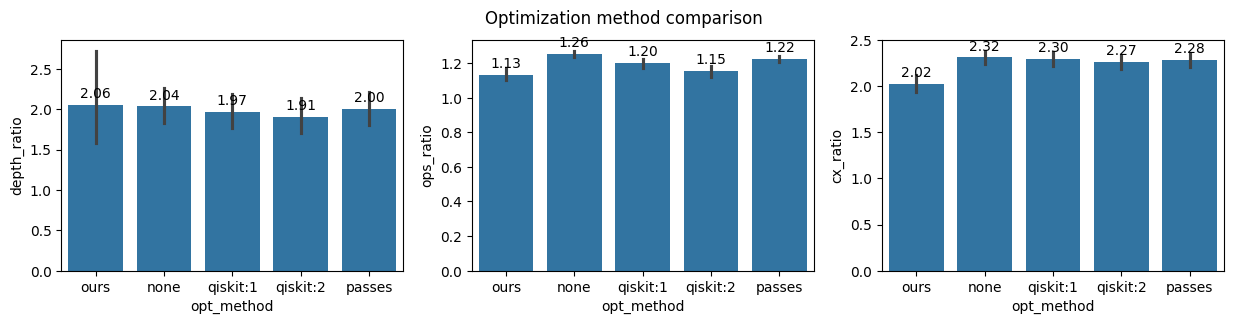

In [69]:
plot_bar_comparison(title='Optimization method comparison', x='opt_method')

也是除了depth都领先。

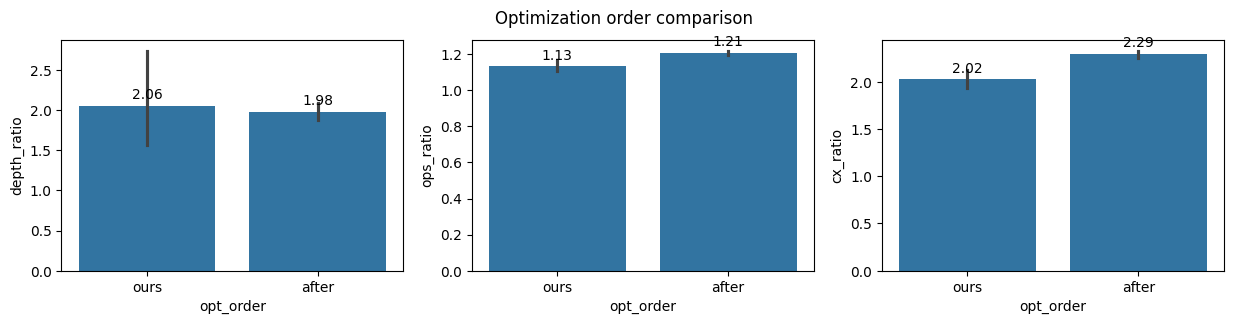

In [70]:
plot_bar_comparison(title='Optimization order comparison', x='opt_order')


除了depth都领先。

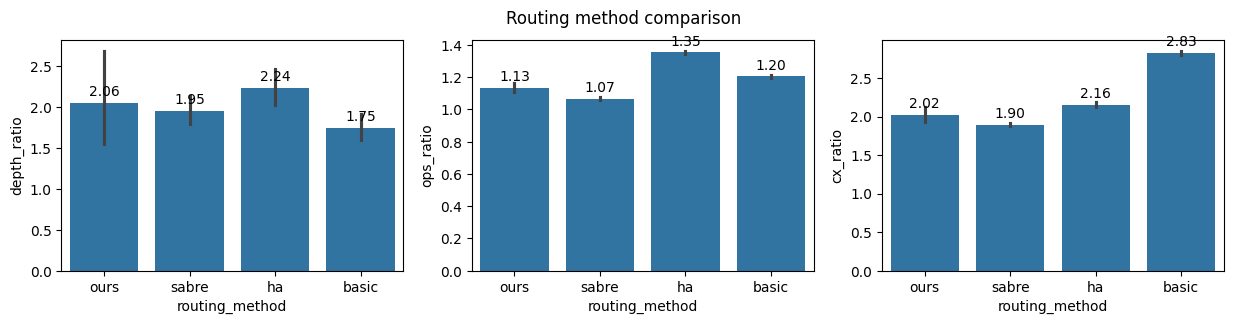

In [71]:
plot_bar_comparison(title='Routing method comparison', x='routing_method')


就比SABRE差，其他都是领先。和HA比较接近，可能是因为用了Bridge？

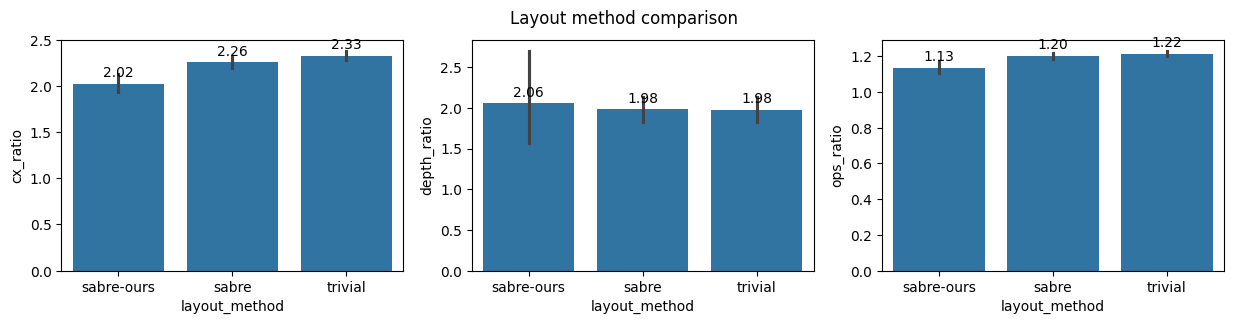

In [64]:
plt.figure(figsize=(15,3))
plt.suptitle('Layout method comparison')

ax = plt.subplot(1,3,1)
sns.barplot(df[df.metric == 'cx_ratio'], hue='metric', y='value', x='layout_method', ax=ax, legend=False)
plt.ylabel('cx_ratio')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', padding=3)

ax = plt.subplot(1,3,2)
sns.barplot(df[df.metric == 'depth_ratio'], hue='metric', y='value', x='layout_method', ax=ax, legend=False)
plt.ylabel('depth_ratio')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', padding=3)

ax = plt.subplot(1,3,3)
sns.barplot(df[df.metric == 'ops_ratio'], hue='metric', y='value', x='layout_method', ax=ax, legend=False)
plt.ylabel('ops_ratio')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', padding=3)


除了depth都领先。